# 08. Robustness, Normalization and Data Augmentation

Notebook này kiểm tra độ bền của mô hình khi bình luận bị viết bẩn, đánh giá hiệu quả normalization và thử nghiệm augmentation cho SVM/XLM-R.

Input chính:
- `data/processed/train_processed.csv`
- `data/processed/val_processed.csv`
- `data/processed/test_processed.csv`

Output chính:
- `data/robustness/`
- `outputs/results/note08/`
- `outputs/figures/note08/`
- `outputs/models/note08/`
- `src/normalization.py`

## 1. Cài thư viện

In [ ]:
# chay tren Colab
!pip -q install -U transformers accelerate sentencepiece scikit-learn joblib matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 97.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


## 2. Mount Drive và cấu hình

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import re
import json
import time
import random
import shutil
import inspect
import unicodedata
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification')

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
ROBUSTNESS_DIR = PROJECT_ROOT / 'data' / 'robustness'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'note08'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'note08'
MODELS_DIR = PROJECT_ROOT / 'outputs' / 'models' / 'note08'
SRC_DIR = PROJECT_ROOT / 'src'

for d in [ROBUSTNESS_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR, SRC_DIR]:
    d.mkdir(parents=True, exist_ok=True)

required_files = [
    PROCESSED_DIR / 'train_processed.csv',
    PROCESSED_DIR / 'val_processed.csv',
    PROCESSED_DIR / 'test_processed.csv',
]
missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError('Thieu file input: ' + '; '.join(missing))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PROCESSED_DIR:', PROCESSED_DIR)
print('ROBUSTNESS_DIR:', ROBUSTNESS_DIR)
print('RESULTS_DIR:', RESULTS_DIR)
print('FIGURES_DIR:', FIGURES_DIR)
print('MODELS_DIR:', MODELS_DIR)

PROJECT_ROOT: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification
PROCESSED_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/data/processed
ROBUSTNESS_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/data/robustness
RESULTS_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08
FIGURES_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/figures/note08
MODELS_DIR: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08


## 3. Config thí nghiệm

In [ ]:
LABEL_NAMES = {0: 'CLEAN', 1: 'OFFENSIVE', 2: 'HATE'}
LABEL_IDS = [0, 1, 2]

# SVM chay nhanh nen mac dinh bat
RUN_SVM_BASELINE = True
RUN_SVM_AUGMENTATION = True

# XLM-R can GPU. Train sample de toi uu thoi gian, evaluate full noisy test.
RUN_XLMR = True
XLMR_MODEL_NAME = 'xlm-roberta-base'
XLMR_NUM_EPOCHS = 1
XLMR_MAX_LENGTH = 96
XLMR_BATCH_SIZE = 16
XLMR_EVAL_BATCH_SIZE = 64
XLMR_LEARNING_RATE = 2e-5
XLMR_WEIGHT_DECAY = 0.01
XLMR_ORIGINAL_SAMPLE = 8000
XLMR_AUG_ORIGINAL_SAMPLE = 8000
XLMR_AUG_NOISE_SAMPLE = 8000

# Neu muon test nhanh hon, co the giam 3 bien sample ve 5000.
NOISE_TYPES = [
    'clean',
    'no_accent',
    'repeated_char',
    'special_char',
    'masked_word',
    'slang_teencode',
    'mixed_noise',
]

print({
    'RUN_SVM_BASELINE': RUN_SVM_BASELINE,
    'RUN_SVM_AUGMENTATION': RUN_SVM_AUGMENTATION,
    'RUN_XLMR': RUN_XLMR,
    'XLMR_ORIGINAL_SAMPLE': XLMR_ORIGINAL_SAMPLE,
    'XLMR_AUG_ORIGINAL_SAMPLE': XLMR_AUG_ORIGINAL_SAMPLE,
    'XLMR_AUG_NOISE_SAMPLE': XLMR_AUG_NOISE_SAMPLE,
    'XLMR_NUM_EPOCHS': XLMR_NUM_EPOCHS,
    'XLMR_MAX_LENGTH': XLMR_MAX_LENGTH,
})

{'RUN_SVM_BASELINE': True, 'RUN_SVM_AUGMENTATION': True, 'RUN_XLMR': True, 'XLMR_ORIGINAL_SAMPLE': 8000, 'XLMR_AUG_ORIGINAL_SAMPLE': 8000, 'XLMR_AUG_NOISE_SAMPLE': 8000, 'XLMR_NUM_EPOCHS': 1, 'XLMR_MAX_LENGTH': 96}


## 4. Đọc dữ liệu

In [ ]:
def read_csv(path):
    return pd.read_csv(path)

train_df = read_csv(PROCESSED_DIR / 'train_processed.csv')
val_df = read_csv(PROCESSED_DIR / 'val_processed.csv')
test_df = read_csv(PROCESSED_DIR / 'test_processed.csv')

def find_text_col(df):
    for c in ['text_clean', 'free_text', 'text', 'comment', 'content']:
        if c in df.columns:
            return c
    raise ValueError('Khong tim thay cot text')

TEXT_COL = find_text_col(train_df)
LABEL_COL = 'label_id' if 'label_id' in train_df.columns else 'label'

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    if LABEL_COL not in df.columns:
        raise ValueError(f'{name} thieu cot label')
    df[TEXT_COL] = df[TEXT_COL].fillna('').astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)

print('TEXT_COL:', TEXT_COL)
print('LABEL_COL:', LABEL_COL)
print('train:', train_df.shape)
print('val:', val_df.shape)
print('test:', test_df.shape)
print(train_df[LABEL_COL].value_counts().sort_index())

TEXT_COL: text_clean
LABEL_COL: label_id
train: (24046, 5)
val: (2672, 5)
test: (6680, 5)
label_id
0    19885
1     1605
2     2556
Name: count, dtype: int64


## 5. Sinh noisy test

In [ ]:
VIETNAMESE_TEENCODE = {
    'không': 'ko', 'khong': 'ko', 'k': 'ko',
    'được': 'dc', 'duoc': 'dc',
    'biết': 'biet', 'biet': 'biet',
    'quá': 'qua', 'qua': 'qua',
    'gì': 'j', 'gi': 'j',
    'vậy': 'z', 'vay': 'z',
    'rồi': 'r', 'roi': 'r',
}

TOXIC_KEYWORDS = [
    'ngu', 'đm', 'dm', 'dmm', 'địt', 'dit', 'mẹ', 'me', 'vl', 'vcl',
    'cc', 'cl', 'óc', 'oc', 'chó', 'cho', 'cặc', 'cac', 'lồn', 'lon'
]

VOWELS = set('aeiouyăâêôơưáàảãạắằẳẵặấầẩẫậéèẻẽẹếềểễệóòỏõọốồổỗộớờởỡợúùủũụứừửữựíìỉĩị')

def remove_accent(text):
    text = str(text)
    text = unicodedata.normalize('NFD', text)
    text = ''.join(ch for ch in text if unicodedata.category(ch) != 'Mn')
    return text.replace('đ', 'd').replace('Đ', 'D')

def repeat_chars(text):
    words = str(text).split()
    out = []
    for w in words:
        lw = w.lower()
        if any(k in lw for k in TOXIC_KEYWORDS) or len(w) <= 4:
            chars = list(w)
            pos = None
            for i in range(len(chars) - 1, -1, -1):
                if chars[i].lower() in VOWELS or chars[i].isalnum():
                    pos = i
                    break
            if pos is not None:
                chars[pos] = chars[pos] * 4
                w = ''.join(chars)
        out.append(w)
    return ' '.join(out)

def insert_special(text):
    s = str(text)
    for kw in sorted(TOXIC_KEYWORDS, key=len, reverse=True):
        pattern = re.compile(re.escape(kw), flags=re.IGNORECASE)
        if pattern.search(s):
            repl = '.'.join(list(kw))
            return pattern.sub(repl, s, count=1)
    words = s.split()
    if words:
        i = min(len(words) - 1, max(0, len(words) // 2))
        words[i] = '.'.join(list(words[i]))
    return ' '.join(words)

def mask_word(text):
    s = str(text)
    for kw in sorted(TOXIC_KEYWORDS, key=len, reverse=True):
        pattern = re.compile(re.escape(kw), flags=re.IGNORECASE)
        if pattern.search(s):
            if len(kw) <= 2:
                repl = kw[0] + '*'
            else:
                repl = kw[0] + '*' * (len(kw) - 2) + kw[-1]
            return pattern.sub(repl, s, count=1)
    words = s.split()
    if words:
        i = min(len(words) - 1, max(0, len(words) // 2))
        w = words[i]
        if len(w) > 2:
            words[i] = w[0] + '*' * (len(w) - 2) + w[-1]
    return ' '.join(words)

def slang_teencode(text):
    words = str(text).split()
    out = []
    for w in words:
        key = w.lower().strip('.,!?;:')
        out.append(VIETNAMESE_TEENCODE.get(key, w))
    return ' '.join(out)

def mixed_noise(text):
    s = remove_accent(text)
    s = slang_teencode(s)
    s = repeat_chars(s)
    s = insert_special(s)
    s = mask_word(s)
    return s

def make_noisy_df(base_df, noise_type):
    if noise_type == 'clean':
        noisy = base_df[TEXT_COL].astype(str)
    elif noise_type == 'no_accent':
        noisy = base_df[TEXT_COL].map(remove_accent)
    elif noise_type == 'repeated_char':
        noisy = base_df[TEXT_COL].map(repeat_chars)
    elif noise_type == 'special_char':
        noisy = base_df[TEXT_COL].map(insert_special)
    elif noise_type == 'masked_word':
        noisy = base_df[TEXT_COL].map(mask_word)
    elif noise_type == 'slang_teencode':
        noisy = base_df[TEXT_COL].map(slang_teencode)
    elif noise_type == 'mixed_noise':
        noisy = base_df[TEXT_COL].map(mixed_noise)
    else:
        raise ValueError(noise_type)

    out = pd.DataFrame({
        'sample_id': np.arange(len(base_df)),
        'original_text': base_df[TEXT_COL].astype(str).values,
        'noisy_text': noisy.values,
        'label_id': base_df[LABEL_COL].astype(int).values,
        'label_name': base_df[LABEL_COL].map(LABEL_NAMES).values,
        'noise_type': noise_type,
    })
    return out

noisy_tests = {}
for noise_type in NOISE_TYPES:
    df_noise = make_noisy_df(test_df, noise_type)
    noisy_tests[noise_type] = df_noise
    df_noise.to_csv(ROBUSTNESS_DIR / f'test_{noise_type}.csv', index=False)

pd.DataFrame([
    {'noise_type': k, 'n_rows': len(v), 'changed_rate': float((v['original_text'] != v['noisy_text']).mean())}
    for k, v in noisy_tests.items()
]).to_csv(RESULTS_DIR / 'noisy_test_summary.csv', index=False)

pd.DataFrame([
    {'noise_type': k, 'original_text': v.iloc[0]['original_text'], 'noisy_text': v.iloc[0]['noisy_text']}
    for k, v in noisy_tests.items()
]).head(10)

,noise_type,original_text,noisy_text
0,clean,Đừng cố biện minh =)))) choi lon,Đừng cố biện minh =)))) choi lon
1,no_accent,Đừng cố biện minh =)))) choi lon,Dung co bien minh =)))) choi lon
2,repeated_char,Đừng cố biện minh =)))) choi lon,Đừngggg cốốốố biệnnnn minhhhh =)))) choiiii lo...
3,special_char,Đừng cố biện minh =)))) choi lon,Đừng cố biện minh =)))) c.h.oi lon
4,masked_word,Đừng cố biện minh =)))) choi lon,Đừng cố biện minh =)))) c*oi lon
5,slang_teencode,Đừng cố biện minh =)))) choi lon,Đừng cố biện minh =)))) choi lon
6,mixed_noise,Đừng cố biện minh =)))) choi lon,Dungggg coooo biennnn minhhhh =)))) c.h.oiiii ...


## 6. Normalization

In [ ]:
TEENCODE_NORMALIZE = {
    'ko': 'không', 'k': 'không', 'khong': 'không',
    'dc': 'được', 'đc': 'được',
    'j': 'gì',
    'z': 'vậy',
    'r': 'rồi',
}

MASK_PATTERNS = [
    (r'\bn[\*\._-]*g[\*\._-]*u\b', 'ngu'),
    (r'\bd[\*\._-]*m\b', 'dm'),
    (r'\bđ[\*\._-]*m\b', 'đm'),
    (r'\bv[\*\._-]*c[\*\._-]*l\b', 'vcl'),
    (r'\bc[\*\._-]*c\b', 'cc'),
]

def reduce_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', str(text))

def strip_special_inside_words(text):
    text = str(text).lower()
    # khong xoa khoang trang
    return re.sub(r'(?<=\w)[\.\*_\-]+(?=\w)', '', text)

def normalize_teencode(text):
    words = str(text).split()
    out = []
    for w in words:
        prefix = re.match(r'^\W*', w).group(0)
        suffix = re.search(r'\W*$', w).group(0)
        core = w[len(prefix): len(w) - len(suffix) if suffix else len(w)]
        out.append(prefix + TEENCODE_NORMALIZE.get(core.lower(), core) + suffix)
    return ' '.join(out)

def normalize_masked_common(text):
    s = str(text).lower()
    for pat, repl in MASK_PATTERNS:
        s = re.sub(pat, repl, s)
    return s

def normalize_comment(text):
    s = unicodedata.normalize('NFC', str(text)).lower()
    s = normalize_masked_common(s)
    s = strip_special_inside_words(s)
    s = reduce_repeated_chars(s)
    s = normalize_teencode(s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# ghi module cho app
normalization_py = r"""
import re
import unicodedata

TEENCODE_NORMALIZE = {
    'ko': 'không', 'k': 'không', 'khong': 'không',
    'dc': 'được', 'đc': 'được',
    'j': 'gì',
    'z': 'vậy',
    'r': 'rồi',
}

MASK_PATTERNS = [
    (r'\bn[\*\._-]*g[\*\._-]*u\b', 'ngu'),
    (r'\bd[\*\._-]*m\b', 'dm'),
    (r'\bđ[\*\._-]*m\b', 'đm'),
    (r'\bv[\*\._-]*c[\*\._-]*l\b', 'vcl'),
    (r'\bc[\*\._-]*c\b', 'cc'),
]

def reduce_repeated_chars(text):
    return re.sub(r'(.)\1{2,}', r'\1', str(text))

def strip_special_inside_words(text):
    text = str(text).lower()
    return re.sub(r'(?<=\w)[\.\*_\-]+(?=\w)', '', text)

def normalize_teencode(text):
    words = str(text).split()
    out = []
    for w in words:
        prefix = re.match(r'^\W*', w).group(0)
        suffix = re.search(r'\W*$', w).group(0)
        core = w[len(prefix): len(w) - len(suffix) if suffix else len(w)]
        out.append(prefix + TEENCODE_NORMALIZE.get(core.lower(), core) + suffix)
    return ' '.join(out)

def normalize_masked_common(text):
    s = str(text).lower()
    for pat, repl in MASK_PATTERNS:
        s = re.sub(pat, repl, s)
    return s

def normalize_comment(text):
    s = unicodedata.normalize('NFC', str(text)).lower()
    s = normalize_masked_common(s)
    s = strip_special_inside_words(s)
    s = reduce_repeated_chars(s)
    s = normalize_teencode(s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s
"""

(SRC_DIR / 'normalization.py').write_text(normalization_py, encoding='utf-8')

examples = pd.DataFrame({
    'input': ['mày nguuuuu quá', 'n.g.u thật', 'ko thích', 'đ*m vl', 'mày ngu quá'],
})
examples['normalized'] = examples['input'].map(normalize_comment)
examples.to_csv(RESULTS_DIR / 'normalization_examples.csv', index=False)
examples

,input,normalized
0,mày nguuuuu quá,mày ngu quá
1,n.g.u thật,ngu thật
2,ko thích,không thích
3,đ*m vl,đm vl
4,mày ngu quá,mày ngu quá


## 7. Hàm đánh giá

In [ ]:
def compute_metrics_from_pred(y_true, y_pred):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=LABEL_IDS, zero_division=0
    )
    out = {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_precision': float(np.mean(precision)),
        'macro_recall': float(np.mean(recall)),
        'macro_f1': float(np.mean(f1)),
    }
    for i, label_id in enumerate(LABEL_IDS):
        name = LABEL_NAMES[label_id].lower()
        out[f'precision_{name}'] = float(precision[i])
        out[f'recall_{name}'] = float(recall[i])
        out[f'f1_{name}'] = float(f1[i])
        out[f'support_{name}'] = int(support[i])
    return out

def add_metric_row(rows, model_name, train_setting, noise_type, eval_text_variant, y_true, y_pred, n_train=None):
    metrics = compute_metrics_from_pred(y_true, y_pred)
    metrics.update({
        'model_name': model_name,
        'train_setting': train_setting,
        'noise_type': noise_type,
        'eval_text_variant': eval_text_variant,
        'n_samples': len(y_true),
        'n_train': n_train,
    })
    rows.append(metrics)
    return metrics

def save_error_cases(model_name, train_setting, noise_type, eval_text_variant, texts, y_true, y_pred, max_rows=80):
    tmp = pd.DataFrame({
        'model_name': model_name,
        'train_setting': train_setting,
        'noise_type': noise_type,
        'eval_text_variant': eval_text_variant,
        'text': texts,
        'y_true': y_true,
        'y_pred': y_pred,
        'true_label': [LABEL_NAMES[int(x)] for x in y_true],
        'pred_label': [LABEL_NAMES[int(x)] for x in y_pred],
    })
    return tmp[tmp['y_true'] != tmp['y_pred']].head(max_rows)

## 8. Robustness với SVM baseline đã có

In [ ]:
all_metrics = []
all_error_cases = []

svm_model_path = PROJECT_ROOT / 'outputs' / 'models' / 'svm_model.joblib'
tfidf_path = PROJECT_ROOT / 'outputs' / 'models' / 'tfidf_vectorizer.joblib'

if RUN_SVM_BASELINE:
    if not svm_model_path.exists() or not tfidf_path.exists():
        print('Khong thay SVM artifact, bo qua SVM baseline.')
    else:
        svm_baseline = joblib.load(svm_model_path)
        tfidf_baseline = joblib.load(tfidf_path)
        for noise_type, df_noise in noisy_tests.items():
            y_true = df_noise['label_id'].astype(int).values

            texts_before = df_noise['noisy_text'].astype(str).tolist()
            pred_before = svm_baseline.predict(tfidf_baseline.transform(texts_before))
            add_metric_row(all_metrics, 'svm_saved_baseline', 'original_artifact', noise_type, 'before_norm', y_true, pred_before)

            if noise_type in ['clean', 'mixed_noise']:
                all_error_cases.append(save_error_cases('svm_saved_baseline', 'original_artifact', noise_type, 'before_norm', texts_before, y_true, pred_before))

            texts_after = [normalize_comment(x) for x in texts_before]
            pred_after = svm_baseline.predict(tfidf_baseline.transform(texts_after))
            add_metric_row(all_metrics, 'svm_saved_baseline', 'original_artifact', noise_type, 'after_norm', y_true, pred_after)

        pd.DataFrame(all_metrics).to_csv(RESULTS_DIR / 'robustness_metrics_svm_saved.csv', index=False)

pd.DataFrame(all_metrics).head()

,accuracy,macro_precision,macro_recall,macro_f1,precision_clean,recall_clean,f1_clean,support_clean,precision_offensive,recall_offensive,...,precision_hate,recall_hate,f1_hate,support_hate,model_name,train_setting,noise_type,eval_text_variant,n_samples,n_train
0,0.863174,0.652172,0.634734,0.642683,0.927234,0.937094,0.932138,5548,0.466146,0.403153,...,0.563135,0.563953,0.563544,688,svm_saved_baseline,original_artifact,clean,before_norm,6680,None
1,0.864671,0.655965,0.637989,0.646226,0.927795,0.937996,0.932867,5548,0.470130,0.407658,...,0.569971,0.568314,0.569141,688,svm_saved_baseline,original_artifact,clean,after_norm,6680,None
2,0.797305,0.520382,0.540652,0.528756,0.906088,0.879957,0.892831,5548,0.278161,0.272523,...,0.376896,0.469477,0.418123,688,svm_saved_baseline,original_artifact,no_accent,before_norm,6680,None
3,0.799401,0.523933,0.541385,0.530850,0.905141,0.882300,0.893574,5548,0.285372,0.268018,...,0.381287,0.473837,0.422553,688,svm_saved_baseline,original_artifact,no_accent,after_norm,6680,None
4,0.823503,0.479702,0.370845,0.375333,0.842826,0.976208,0.904627,5548,0.192771,0.036036,...,0.403509,0.100291,0.160652,688,svm_saved_baseline,original_artifact,repeated_char,before_norm,6680,None


## 9. Data augmentation cho SVM

In [ ]:
def build_augmented_train(base_df):
    rows = []
    base = base_df[[TEXT_COL, LABEL_COL]].copy()
    base = base.rename(columns={TEXT_COL: 'text', LABEL_COL: 'label_id'})
    base['source'] = 'original'
    base['noise_type'] = 'clean'
    rows.append(base)

    funcs = {
        'no_accent': remove_accent,
        'repeated_char': repeat_chars,
        'special_char': insert_special,
        'masked_word': mask_word,
        'slang_teencode': slang_teencode,
        'mixed_noise': mixed_noise,
    }
    for noise_type, fn in funcs.items():
        aug = pd.DataFrame({
            'text': base_df[TEXT_COL].astype(str).map(fn),
            'label_id': base_df[LABEL_COL].astype(int),
            'source': 'augmented',
            'noise_type': noise_type,
        })
        rows.append(aug)
    return pd.concat(rows, ignore_index=True)

aug_train_df = build_augmented_train(train_df)
aug_train_df.to_csv(ROBUSTNESS_DIR / 'augmented_train_mixed.csv', index=False)
print('augmented_train:', aug_train_df.shape)
aug_train_df['noise_type'].value_counts()

augmented_train: (168322, 4)


,count
noise_type,
clean,24046
no_accent,24046
repeated_char,24046
special_char,24046
masked_word,24046
slang_teencode,24046
mixed_noise,24046


In [ ]:
def train_svm_model(train_texts, train_labels, model_dir, tag):
    model_dir.mkdir(parents=True, exist_ok=True)
    vectorizer = TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True,
    )
    x_train = vectorizer.fit_transform(train_texts)
    clf = LinearSVC(class_weight='balanced', random_state=SEED)
    clf.fit(x_train, train_labels)
    joblib.dump(vectorizer, model_dir / f'tfidf_{tag}.joblib')
    joblib.dump(clf, model_dir / f'svm_{tag}.joblib')
    return vectorizer, clf

if RUN_SVM_AUGMENTATION:
    t0 = time.time()
    tfidf_orig, svm_orig = train_svm_model(
        train_df[TEXT_COL].astype(str).tolist(),
        train_df[LABEL_COL].astype(int).tolist(),
        MODELS_DIR,
        'original_note08',
    )
    print('SVM original trained in', round(time.time() - t0, 2), 's')

    t0 = time.time()
    tfidf_aug, svm_aug = train_svm_model(
        aug_train_df['text'].astype(str).tolist(),
        aug_train_df['label_id'].astype(int).tolist(),
        MODELS_DIR,
        'augmented_mixed_note08',
    )
    print('SVM augmented trained in', round(time.time() - t0, 2), 's')

    for model_name, train_setting, vectorizer, clf, n_train in [
        ('svm_note08', 'original', tfidf_orig, svm_orig, len(train_df)),
        ('svm_note08', 'augmented_mixed', tfidf_aug, svm_aug, len(aug_train_df)),
    ]:
        for noise_type, df_noise in noisy_tests.items():
            y_true = df_noise['label_id'].astype(int).values
            texts_before = df_noise['noisy_text'].astype(str).tolist()
            pred_before = clf.predict(vectorizer.transform(texts_before))
            add_metric_row(all_metrics, model_name, train_setting, noise_type, 'before_norm', y_true, pred_before, n_train=n_train)

            texts_after = [normalize_comment(x) for x in texts_before]
            pred_after = clf.predict(vectorizer.transform(texts_after))
            add_metric_row(all_metrics, model_name, train_setting, noise_type, 'after_norm', y_true, pred_after, n_train=n_train)

pd.DataFrame(all_metrics).tail()

SVM original trained in 2.38 s
SVM augmented trained in 16.65 s


,accuracy,macro_precision,macro_recall,macro_f1,precision_clean,recall_clean,f1_clean,support_clean,precision_offensive,recall_offensive,...,precision_hate,recall_hate,f1_hate,support_hate,model_name,train_setting,noise_type,eval_text_variant,n_samples,n_train
37,0.838623,0.590496,0.560155,0.573606,0.904511,0.928803,0.916496,5548,0.350282,0.279279,...,0.516693,0.472384,0.493546,688,svm_note08,augmented_mixed,masked_word,after_norm,6680,168322.0
38,0.852545,0.624217,0.602965,0.612704,0.919077,0.933490,0.926227,5548,0.415344,0.353604,...,0.538231,0.521802,0.529889,688,svm_note08,augmented_mixed,slang_teencode,before_norm,6680,168322.0
39,0.853743,0.628170,0.604453,0.615182,0.918660,0.934391,0.926459,5548,0.421622,0.351351,...,0.544228,0.527616,0.535793,688,svm_note08,augmented_mixed,slang_teencode,after_norm,6680,168322.0
40,0.841467,0.596172,0.585030,0.590279,0.915551,0.924297,0.919903,5548,0.357500,0.322072,...,0.515464,0.508721,0.512070,688,svm_note08,augmented_mixed,mixed_noise,before_norm,6680,168322.0
41,0.832036,0.582092,0.579547,0.580636,0.912019,0.913663,0.912840,5548,0.346247,0.322072,...,0.488011,0.502907,0.495347,688,svm_note08,augmented_mixed,mixed_noise,after_norm,6680,168322.0


## 10. XLM-R multilingual classification

In [ ]:
def balanced_sample(df, n_total, text_col='text', label_col='label_id', seed=SEED):
    df = df[[text_col, label_col]].copy()
    df[text_col] = df[text_col].fillna('').astype(str)
    df[label_col] = df[label_col].astype(int)
    per_class = max(1, n_total // len(LABEL_IDS))
    parts = []
    for label_id in LABEL_IDS:
        sub = df[df[label_col] == label_id]
        if len(sub) == 0:
            continue
        replace = len(sub) < per_class
        parts.append(sub.sample(n=per_class, replace=replace, random_state=seed + int(label_id)))
    out = pd.concat(parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    return out

xlmr_original_train = balanced_sample(
    train_df.rename(columns={TEXT_COL: 'text', LABEL_COL: 'label_id'}),
    XLMR_ORIGINAL_SAMPLE,
)

aug_noise_only = aug_train_df[aug_train_df['source'] == 'augmented'][['text', 'label_id']].copy()
xlmr_aug_original = balanced_sample(
    train_df.rename(columns={TEXT_COL: 'text', LABEL_COL: 'label_id'}),
    XLMR_AUG_ORIGINAL_SAMPLE,
)
xlmr_aug_noise = balanced_sample(
    aug_noise_only,
    XLMR_AUG_NOISE_SAMPLE,
)
xlmr_augmented_train = pd.concat([xlmr_aug_original, xlmr_aug_noise], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

xlmr_original_train.to_csv(ROBUSTNESS_DIR / 'xlmr_original_train_sample.csv', index=False)
xlmr_augmented_train.to_csv(ROBUSTNESS_DIR / 'xlmr_augmented_train_sample.csv', index=False)

print('xlmr_original_train:', xlmr_original_train.shape)
print(xlmr_original_train['label_id'].value_counts().sort_index())
print('xlmr_augmented_train:', xlmr_augmented_train.shape)
print(xlmr_augmented_train['label_id'].value_counts().sort_index())

xlmr_original_train: (7998, 2)
label_id
0    2666
1    2666
2    2666
Name: count, dtype: int64
xlmr_augmented_train: (15996, 2)
label_id
0    5332
1    5332
2    5332
Name: count, dtype: int64


In [ ]:
import torch
from torch import nn
from torch.utils.data import Dataset

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.labels = [int(x) for x in labels]
        self.enc = tokenizer(
            [str(x) for x in texts],
            truncation=True,
            padding='max_length',
            max_length=max_length,
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        else:
            loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

def make_training_args(output_dir, run_name):
    params = inspect.signature(TrainingArguments.__init__).parameters
    kwargs = {
        'output_dir': str(output_dir),
        'num_train_epochs': XLMR_NUM_EPOCHS,
        'learning_rate': XLMR_LEARNING_RATE,
        'weight_decay': XLMR_WEIGHT_DECAY,
        'per_device_train_batch_size': XLMR_BATCH_SIZE,
        'per_device_eval_batch_size': XLMR_EVAL_BATCH_SIZE,
        'logging_steps': 50,
        'save_strategy': 'no',
        'report_to': 'none',
        'seed': SEED,
        'disable_tqdm': False,
        'dataloader_num_workers': 2,
        'remove_unused_columns': True,
    }
    if 'eval_strategy' in params:
        kwargs['eval_strategy'] = 'epoch'
    elif 'evaluation_strategy' in params:
        kwargs['evaluation_strategy'] = 'epoch'
    if 'fp16' in params:
        kwargs['fp16'] = torch.cuda.is_available()
    if 'run_name' in params:
        kwargs['run_name'] = run_name
    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in params})

def trainer_init_kwargs(model, args, train_dataset, eval_dataset, tokenizer, class_weights):
    kwargs = {
        'model': model,
        'args': args,
        'train_dataset': train_dataset,
        'eval_dataset': eval_dataset,
        'class_weights': class_weights,
    }
    sig = inspect.signature(Trainer.__init__).parameters
    if 'processing_class' in sig:
        kwargs['processing_class'] = tokenizer
    elif 'tokenizer' in sig:
        kwargs['tokenizer'] = tokenizer
    return kwargs

def compute_hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': precision_recall_fscore_support(labels, preds, labels=LABEL_IDS, average='macro', zero_division=0)[2],
    }

def train_xlmr_classifier(train_data, val_data, output_dir, run_name):
    if DEVICE.type != 'cuda':
        raise RuntimeError('Khong thay GPU CUDA trong runtime hien tai. Hay chon T4 GPU, restart runtime va Run all lai.')
    tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        XLMR_MODEL_NAME,
        num_labels=3,
        id2label=LABEL_NAMES,
        label2id={v: k for k, v in LABEL_NAMES.items()},
    )
    train_dataset = TextClassificationDataset(train_data['text'].tolist(), train_data['label_id'].tolist(), tokenizer, XLMR_MAX_LENGTH)
    eval_dataset = TextClassificationDataset(val_data['text'].tolist(), val_data['label_id'].tolist(), tokenizer, XLMR_MAX_LENGTH)

    classes = np.array(LABEL_IDS)
    weights = compute_class_weight('balanced', classes=classes, y=train_data['label_id'].astype(int).values)
    class_weights = torch.tensor(weights, dtype=torch.float)

    args = make_training_args(output_dir, run_name)
    trainer = WeightedTrainer(
        **trainer_init_kwargs(model, args, train_dataset, eval_dataset, tokenizer, class_weights),
        compute_metrics=compute_hf_metrics,
    )
    train_result = trainer.train()
    trainer.save_model(str(output_dir))
    tokenizer.save_pretrained(str(output_dir))
    return trainer, tokenizer, train_result

def predict_xlmr(trainer, tokenizer, texts):
    dummy_labels = [0] * len(texts)
    dataset = TextClassificationDataset(texts, dummy_labels, tokenizer, XLMR_MAX_LENGTH)
    output = trainer.predict(dataset)
    return np.argmax(output.predictions, axis=-1)

Device: cuda


In [ ]:
xlmr_metrics_rows = []

if RUN_XLMR:
    val_for_xlmr = val_df[[TEXT_COL, LABEL_COL]].copy().rename(columns={TEXT_COL: 'text', LABEL_COL: 'label_id'})

    t0 = time.time()
    xlmr_orig_dir = MODELS_DIR / 'xlmr_original_balanced_sample'
    xlmr_orig_trainer, xlmr_orig_tok, xlmr_orig_log = train_xlmr_classifier(
        xlmr_original_train,
        val_for_xlmr,
        xlmr_orig_dir,
        'xlmr_original_balanced_sample',
    )
    print('XLM-R original trained in', round(time.time() - t0, 2), 's')

    t0 = time.time()
    xlmr_aug_dir = MODELS_DIR / 'xlmr_augmented_balanced_sample'
    xlmr_aug_trainer, xlmr_aug_tok, xlmr_aug_log = train_xlmr_classifier(
        xlmr_augmented_train,
        val_for_xlmr,
        xlmr_aug_dir,
        'xlmr_augmented_balanced_sample',
    )
    print('XLM-R augmented trained in', round(time.time() - t0, 2), 's')

    for model_name, train_setting, trainer, tokenizer, n_train in [
        ('xlmr_note08', 'original', xlmr_orig_trainer, xlmr_orig_tok, len(xlmr_original_train)),
        ('xlmr_note08', 'augmented_mixed', xlmr_aug_trainer, xlmr_aug_tok, len(xlmr_augmented_train)),
    ]:
        for noise_type, df_noise in noisy_tests.items():
            y_true = df_noise['label_id'].astype(int).values
            texts_before = df_noise['noisy_text'].astype(str).tolist()
            pred_before = predict_xlmr(trainer, tokenizer, texts_before)
            row = add_metric_row(all_metrics, model_name, train_setting, noise_type, 'before_norm', y_true, pred_before, n_train=n_train)
            xlmr_metrics_rows.append(row)

            texts_after = [normalize_comment(x) for x in texts_before]
            pred_after = predict_xlmr(trainer, tokenizer, texts_after)
            row = add_metric_row(all_metrics, model_name, train_setting, noise_type, 'after_norm', y_true, pred_after, n_train=n_train)
            xlmr_metrics_rows.append(row)

        # luu loi cho mixed_noise cua XLM-R
        df_mixed = noisy_tests['mixed_noise']
        y_true = df_mixed['label_id'].astype(int).values
        pred_mixed = predict_xlmr(trainer, tokenizer, df_mixed['noisy_text'].astype(str).tolist())
        all_error_cases.append(save_error_cases(model_name, train_setting, 'mixed_noise', 'before_norm', df_mixed['noisy_text'].astype(str).tolist(), y_true, pred_mixed))

pd.DataFrame(xlmr_metrics_rows).head()

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

...

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.880901,0.825404,0.666916,0.506439


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

XLM-R augmented trained in 150.62 s


,accuracy,macro_precision,macro_recall,macro_f1,precision_clean,recall_clean,f1_clean,support_clean,precision_offensive,recall_offensive,...,precision_hate,recall_hate,f1_hate,support_hate,model_name,train_setting,noise_type,eval_text_variant,n_samples,n_train
0,0.647605,0.473481,0.606134,0.481063,0.949740,0.657354,0.776949,5548,0.161721,0.490991,...,0.308981,0.670058,0.422936,688,xlmr_note08,original,clean,before_norm,6680,7998
1,0.619910,0.465743,0.596242,0.464950,0.948479,0.623828,0.752637,5548,0.145778,0.497748,...,0.302970,0.667151,0.416704,688,xlmr_note08,original,clean,after_norm,6680,7998
2,0.313922,0.401348,0.472473,0.269505,0.951102,0.248919,0.394571,5548,0.099010,0.360360,...,0.153931,0.808140,0.258605,688,xlmr_note08,original,no_accent,before_norm,6680,7998
3,0.288922,0.399047,0.464936,0.253192,0.952006,0.218097,0.354891,5548,0.091986,0.367117,...,0.153148,0.809593,0.257572,688,xlmr_note08,original,no_accent,after_norm,6680,7998
4,0.396257,0.433823,0.515133,0.343053,0.955202,0.357426,0.520199,5548,0.089942,0.628378,...,0.256325,0.559593,0.351598,688,xlmr_note08,original,repeated_char,before_norm,6680,7998


## 11. Tổng hợp kết quả

In [ ]:
metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df[
    ['model_name', 'train_setting', 'noise_type', 'eval_text_variant', 'n_samples', 'n_train',
     'accuracy', 'macro_precision', 'macro_recall', 'macro_f1',
     'f1_clean', 'f1_offensive', 'f1_hate',
     'support_clean', 'support_offensive', 'support_hate']
]

before_df = metrics_df[metrics_df['eval_text_variant'] == 'before_norm'].copy()
after_df = metrics_df[metrics_df['eval_text_variant'] == 'after_norm'].copy()

metrics_df.to_csv(RESULTS_DIR / 'robustness_all_metrics.csv', index=False)
before_df.to_csv(RESULTS_DIR / 'robustness_metrics_before_norm.csv', index=False)
after_df.to_csv(RESULTS_DIR / 'robustness_metrics_after_norm.csv', index=False)

metrics_df.sort_values(['model_name', 'train_setting', 'eval_text_variant', 'noise_type']).head(20)

,model_name,train_setting,noise_type,eval_text_variant,n_samples,n_train,accuracy,macro_precision,macro_recall,macro_f1,f1_clean,f1_offensive,f1_hate,support_clean,support_offensive,support_hate
29,svm_note08,augmented_mixed,clean,after_norm,6680,168322.0,0.853892,0.628998,0.604513,0.615527,0.926472,0.384710,0.535398,5548,444,688
37,svm_note08,augmented_mixed,masked_word,after_norm,6680,168322.0,0.838623,0.590496,0.560155,0.573606,0.916496,0.310777,0.493546,5548,444,688
41,svm_note08,augmented_mixed,mixed_noise,after_norm,6680,168322.0,0.832036,0.582092,0.579547,0.580636,0.912840,0.333722,0.495347,5548,444,688
31,svm_note08,augmented_mixed,no_accent,after_norm,6680,168322.0,0.848353,0.618589,0.611052,0.614410,0.923118,0.391459,0.528653,5548,444,688
33,svm_note08,augmented_mixed,repeated_char,after_norm,6680,168322.0,0.852395,0.626631,0.601474,0.612927,0.925522,0.387255,0.526003,5548,444,688
39,svm_note08,augmented_mixed,slang_teencode,after_norm,6680,168322.0,0.853743,0.628170,0.604453,0.615182,0.926459,0.383292,0.535793,5548,444,688
35,svm_note08,augmented_mixed,special_char,after_norm,6680,168322.0,0.853743,0.628608,0.604453,0.615337,0.926376,0.384236,0.535398,5548,444,688
28,svm_note08,augmented_mixed,clean,before_norm,6680,168322.0,0.854192,0.629705,0.605590,0.616474,0.926816,0.388684,0.533923,5548,444,688
36,svm_note08,augmented_mixed,masked_word,before_norm,6680,168322.0,0.847156,0.606961,0.559278,0.579406,0.922057,0.309493,0.506667,5548,444,688
40,svm_note08,augmented_mixed,mixed_noise,before_norm,6680,168322.0,0.841467,0.596172,0.585030,0.590279,0.919903,0.338863,0.512070,5548,444,688


In [ ]:
# F1 drop so voi clean cua cung model/setting/variant
rows = []
for (model_name, train_setting, eval_variant), group in metrics_df.groupby(['model_name', 'train_setting', 'eval_text_variant']):
    clean = group[group['noise_type'] == 'clean']
    if clean.empty:
        continue
    clean_f1 = float(clean.iloc[0]['macro_f1'])
    for _, r in group.iterrows():
        rows.append({
            'model_name': model_name,
            'train_setting': train_setting,
            'eval_text_variant': eval_variant,
            'noise_type': r['noise_type'],
            'clean_macro_f1': clean_f1,
            'macro_f1': r['macro_f1'],
            'f1_drop': clean_f1 - r['macro_f1'],
        })

f1_drop_df = pd.DataFrame(rows)
f1_drop_df.to_csv(RESULTS_DIR / 'robustness_f1_drop.csv', index=False)
f1_drop_df.head()

,model_name,train_setting,eval_text_variant,noise_type,clean_macro_f1,macro_f1,f1_drop
0,svm_note08,augmented_mixed,after_norm,clean,0.615527,0.615527,0.000000
1,svm_note08,augmented_mixed,after_norm,no_accent,0.615527,0.614410,0.001117
2,svm_note08,augmented_mixed,after_norm,repeated_char,0.615527,0.612927,0.002600
3,svm_note08,augmented_mixed,after_norm,special_char,0.615527,0.615337,0.000190
4,svm_note08,augmented_mixed,after_norm,masked_word,0.615527,0.573606,0.041920


In [ ]:
# Normalization recovery: after_norm - before_norm
pivot = metrics_df.pivot_table(
    index=['model_name', 'train_setting', 'noise_type'],
    columns='eval_text_variant',
    values='macro_f1',
    aggfunc='first',
).reset_index()
if {'before_norm', 'after_norm'}.issubset(set(pivot.columns)):
    pivot['macro_f1_recovery'] = pivot['after_norm'] - pivot['before_norm']
else:
    pivot['macro_f1_recovery'] = np.nan
pivot.to_csv(RESULTS_DIR / 'normalization_recovery_summary.csv', index=False)
pivot.sort_values('macro_f1_recovery', ascending=False).head(20)

eval_text_variant,model_name,train_setting,noise_type,after_norm,before_norm,macro_f1_recovery
11,svm_note08,original,repeated_char,0.636411,0.364877,0.271533
18,svm_saved_baseline,original_artifact,repeated_char,0.639597,0.375333,0.264264
9,svm_note08,original,mixed_noise,0.510552,0.362353,0.148199
16,svm_saved_baseline,original_artifact,mixed_noise,0.515091,0.371508,0.143582
32,xlmr_note08,original,repeated_char,0.462534,0.343053,0.119481
34,xlmr_note08,original,special_char,0.464371,0.383394,0.080977
25,xlmr_note08,augmented_mixed,repeated_char,0.481205,0.405808,0.075398
13,svm_note08,original,special_char,0.640490,0.569468,0.071022
20,svm_saved_baseline,original_artifact,special_char,0.645849,0.580484,0.065365
27,xlmr_note08,augmented_mixed,special_char,0.480368,0.421474,0.058894


In [ ]:
# Augmentation gain: augmented_mixed - original
aug_rows = []
for (model_name, noise_type, eval_variant), group in metrics_df.groupby(['model_name', 'noise_type', 'eval_text_variant']):
    orig = group[group['train_setting'] == 'original']
    aug = group[group['train_setting'] == 'augmented_mixed']
    if orig.empty or aug.empty:
        continue
    aug_rows.append({
        'model_name': model_name,
        'noise_type': noise_type,
        'eval_text_variant': eval_variant,
        'original_macro_f1': float(orig.iloc[0]['macro_f1']),
        'augmented_macro_f1': float(aug.iloc[0]['macro_f1']),
        'augmentation_gain_macro_f1': float(aug.iloc[0]['macro_f1'] - orig.iloc[0]['macro_f1']),
        'original_accuracy': float(orig.iloc[0]['accuracy']),
        'augmented_accuracy': float(aug.iloc[0]['accuracy']),
        'augmentation_gain_accuracy': float(aug.iloc[0]['accuracy'] - orig.iloc[0]['accuracy']),
    })

aug_compare_df = pd.DataFrame(aug_rows)
aug_compare_df.to_csv(RESULTS_DIR / 'augmentation_vs_original_comparison.csv', index=False)
aug_compare_df.sort_values('augmentation_gain_macro_f1', ascending=False).head(20)

,model_name,noise_type,eval_text_variant,original_macro_f1,augmented_macro_f1,augmentation_gain_macro_f1,original_accuracy,augmented_accuracy,augmentation_gain_accuracy
9,svm_note08,repeated_char,before_norm,0.364877,0.635174,0.270297,0.824401,0.861078,0.036677
5,svm_note08,mixed_noise,before_norm,0.362353,0.590279,0.227926,0.765719,0.841467,0.075749
19,xlmr_note08,mixed_noise,before_norm,0.182730,0.308477,0.125747,0.246108,0.349701,0.103593
21,xlmr_note08,no_accent,before_norm,0.269505,0.353778,0.084272,0.313922,0.446407,0.132485
6,svm_note08,no_accent,after_norm,0.530312,0.614410,0.084098,0.805389,0.848353,0.042964
7,svm_note08,no_accent,before_norm,0.530521,0.611899,0.081378,0.804491,0.847455,0.042964
4,svm_note08,mixed_noise,after_norm,0.510552,0.580636,0.070084,0.801796,0.832036,0.030240
20,xlmr_note08,no_accent,after_norm,0.253192,0.318328,0.065136,0.288922,0.385479,0.096557
18,xlmr_note08,mixed_noise,after_norm,0.235002,0.299246,0.064245,0.255240,0.345958,0.090719
23,xlmr_note08,repeated_char,before_norm,0.343053,0.405808,0.062755,0.396257,0.517066,0.120808


## 12. So sánh với baseline cũ

In [ ]:
def read_metric_csv(path):
    if not path.exists():
        return {}
    df = pd.read_csv(path)
    cols_lower = {c.lower(): c for c in df.columns}
    out = {}

    if 'metric' in cols_lower and 'value' in cols_lower:
        mcol, vcol = cols_lower['metric'], cols_lower['value']
        for _, r in df.iterrows():
            key = str(r[mcol]).strip().lower().replace(' ', '_')
            try:
                out[key] = float(r[vcol])
            except Exception:
                pass

    if len(df) >= 1:
        row = df.iloc[0]
        for col in df.columns:
            key = str(col).strip().lower().replace(' ', '_')
            try:
                out[key] = float(row[col])
            except Exception:
                pass

    aliases = {
        'accuracy': ['accuracy', 'test_accuracy'],
        'macro_f1': ['macro_f1', 'macro_f1_score', 'macro_avg_f1', 'macro_avg_f1-score', 'macro avg_f1-score', 'test_macro_f1'],
        'macro_precision': ['macro_precision', 'macro_avg_precision', 'macro avg_precision'],
        'macro_recall': ['macro_recall', 'macro_avg_recall', 'macro avg_recall'],
    }
    final = {}
    for target, keys in aliases.items():
        for k in keys:
            if k in out:
                final[target] = out[k]
                break
    return final

def read_report_csv(path):
    if not path.exists():
        return {}
    df = pd.read_csv(path)
    out = {}

    # dua cot dau tien thanh index neu co dang label/class
    if df.shape[1] >= 2 and df.columns[0].lower().startswith('unnamed'):
        df = df.set_index(df.columns[0])
    elif df.shape[1] >= 2 and df.columns[0].lower() in ['label', 'class', 'index']:
        df = df.set_index(df.columns[0])

    idx = [str(x).strip().lower() for x in df.index]
    col_map = {str(c).strip().lower(): c for c in df.columns}

    macro_pos = None
    for i, name in enumerate(idx):
        if name in ['macro avg', 'macro_avg', 'macro']:
            macro_pos = i
            break
    if macro_pos is not None:
        row = df.iloc[macro_pos]
        for target, candidates in {
            'macro_precision': ['precision'],
            'macro_recall': ['recall'],
            'macro_f1': ['f1-score', 'f1_score', 'f1'],
        }.items():
            for cand in candidates:
                if cand in col_map:
                    try:
                        out[target] = float(row[col_map[cand]])
                    except Exception:
                        pass
                    break

    # accuracy co the la row rieng hoac col rieng
    if 'accuracy' in idx:
        row = df.iloc[idx.index('accuracy')]
        for c in df.columns:
            try:
                val = float(row[c])
                if not np.isnan(val):
                    out['accuracy'] = val
                    break
            except Exception:
                pass
    return out

baseline_rows = []
for model_name, metric_file, report_file in [
    ('svm_baseline_note02', 'svm_metrics.csv', 'svm_classification_report.csv'),
    ('bilstm_baseline_note03', 'bilstm_metrics.csv', 'bilstm_report.csv'),
    ('phobert_baseline_note04', 'phobert_metrics.csv', 'phobert_classification_report.csv'),
]:
    m = read_metric_csv(PROJECT_ROOT / 'outputs' / 'results' / metric_file)
    r = read_report_csv(PROJECT_ROOT / 'outputs' / 'results' / report_file)
    merged = {**r, **m}  # metric file uu tien hon report neu co
    baseline_rows.append({
        'model_name': model_name,
        'source': metric_file,
        'accuracy': merged.get('accuracy', np.nan),
        'macro_f1': merged.get('macro_f1', np.nan),
        'macro_precision': merged.get('macro_precision', np.nan),
        'macro_recall': merged.get('macro_recall', np.nan),
    })

clean_xlmr = metrics_df[
    (metrics_df['model_name'] == 'xlmr_note08') &
    (metrics_df['noise_type'] == 'clean') &
    (metrics_df['eval_text_variant'] == 'before_norm')
]
for _, r in clean_xlmr.iterrows():
    baseline_rows.append({
        'model_name': f"xlmr_note08_{r['train_setting']}",
        'source': 'note08',
        'accuracy': r['accuracy'],
        'macro_f1': r['macro_f1'],
        'macro_precision': r['macro_precision'],
        'macro_recall': r['macro_recall'],
    })

comparison_df = pd.DataFrame(baseline_rows)
comparison_df.to_csv(RESULTS_DIR / 'multilingual_vs_phobert_comparison.csv', index=False)
comparison_df

,model_name,source,accuracy,macro_f1,macro_precision,macro_recall
0,svm_baseline_note02,svm_metrics.csv,0.863200,0.642683,0.652172,0.634734
1,bilstm_baseline_note03,bilstm_metrics.csv,0.829300,0.614981,0.589514,0.651247
2,phobert_baseline_note04,phobert_metrics.csv,0.858800,0.665801,0.649606,0.693646
3,xlmr_note08_original,note08,0.647605,0.481063,0.473481,0.606134
4,xlmr_note08_augmented_mixed,note08,0.669910,0.496593,0.482427,0.620214


## 13. Biểu đồ

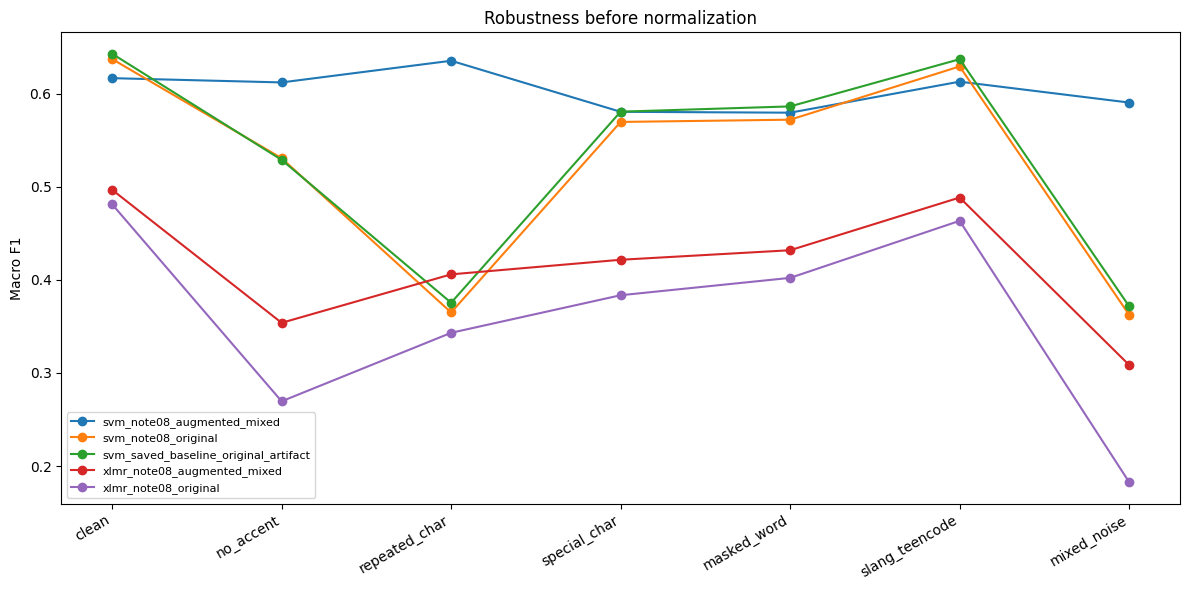

In [ ]:
plot_df = before_df.copy()
keep_models = ['svm_saved_baseline', 'svm_note08', 'xlmr_note08']
plot_df = plot_df[plot_df['model_name'].isin(keep_models)]
plot_df['model_setting'] = plot_df['model_name'] + '_' + plot_df['train_setting']

plt.figure(figsize=(12, 6))
for setting, sub in plot_df.groupby('model_setting'):
    sub = sub.set_index('noise_type').reindex(NOISE_TYPES).reset_index()
    plt.plot(sub['noise_type'], sub['macro_f1'], marker='o', label=setting)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Macro F1')
plt.title('Robustness before normalization')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'robustness_f1_by_noise_type.png', dpi=160)
plt.show()

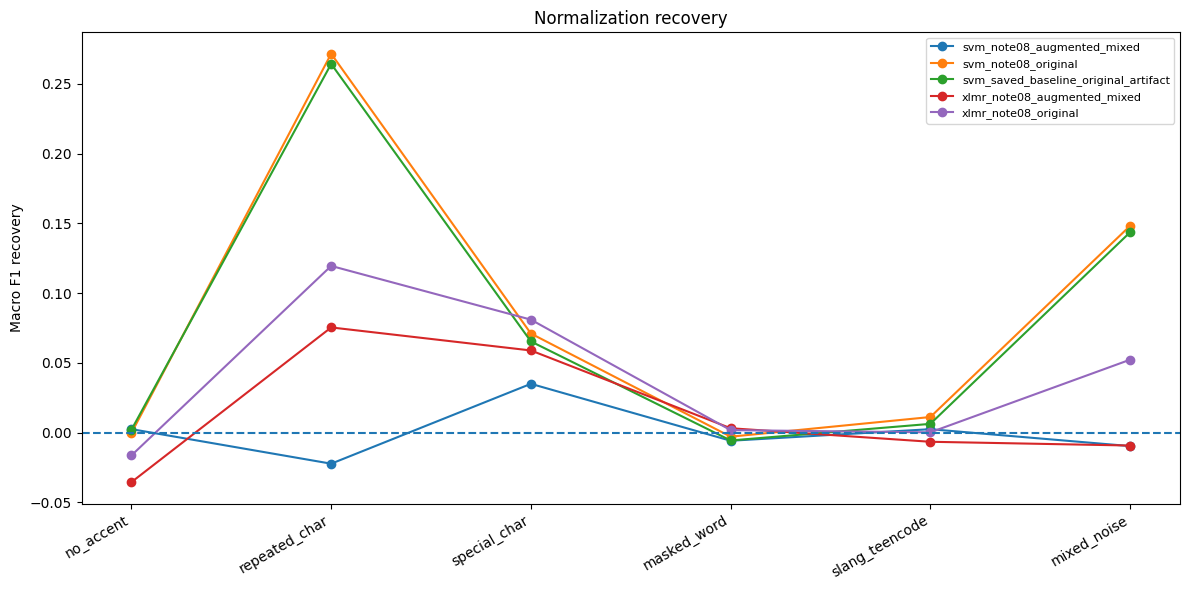

In [ ]:
rec_plot = pivot.copy()
rec_plot = rec_plot[rec_plot['noise_type'] != 'clean']
rec_plot['model_setting'] = rec_plot['model_name'] + '_' + rec_plot['train_setting']

plt.figure(figsize=(12, 6))
for setting, sub in rec_plot.groupby('model_setting'):
    sub = sub.set_index('noise_type').reindex([x for x in NOISE_TYPES if x != 'clean']).reset_index()
    plt.plot(sub['noise_type'], sub['macro_f1_recovery'], marker='o', label=setting)
plt.axhline(0, linestyle='--')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Macro F1 recovery')
plt.title('Normalization recovery')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'normalization_recovery.png', dpi=160)
plt.show()

<Figure size 1200x600 with 0 Axes>

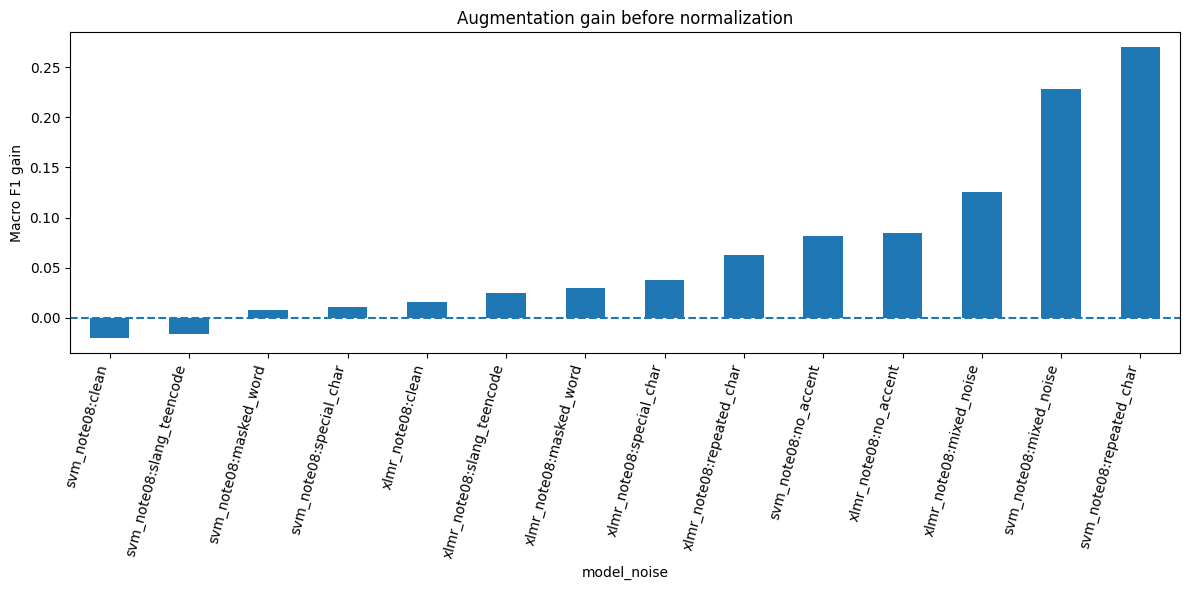

In [ ]:
if not aug_compare_df.empty:
    aug_plot = aug_compare_df[aug_compare_df['eval_text_variant'] == 'before_norm'].copy()
    aug_plot['model_noise'] = aug_plot['model_name'] + ':' + aug_plot['noise_type']
    plt.figure(figsize=(12, 6))
    aug_plot.sort_values('augmentation_gain_macro_f1').plot(
        x='model_noise',
        y='augmentation_gain_macro_f1',
        kind='bar',
        legend=False,
        figsize=(12, 6),
    )
    plt.axhline(0, linestyle='--')
    plt.ylabel('Macro F1 gain')
    plt.title('Augmentation gain before normalization')
    plt.xticks(rotation=75, ha='right')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'augmentation_macro_f1_gain.png', dpi=160)
    plt.show()

## 14. Lưu error cases và run config

In [ ]:
if all_error_cases:
    error_cases_df = pd.concat(all_error_cases, ignore_index=True)
else:
    error_cases_df = pd.DataFrame()
error_cases_df.to_csv(RESULTS_DIR / 'robustness_error_cases.csv', index=False)

run_config = {
    'run_time': datetime.now().isoformat(),
    'project_root': str(PROJECT_ROOT),
    'text_col': TEXT_COL,
    'label_col': LABEL_COL,
    'noise_types': NOISE_TYPES,
    'run_svm_baseline': RUN_SVM_BASELINE,
    'run_svm_augmentation': RUN_SVM_AUGMENTATION,
    'run_xlmr': RUN_XLMR,
    'xlmr_model_name': XLMR_MODEL_NAME,
    'xlmr_num_epochs': XLMR_NUM_EPOCHS,
    'xlmr_max_length': XLMR_MAX_LENGTH,
    'xlmr_batch_size': XLMR_BATCH_SIZE,
    'xlmr_eval_batch_size': XLMR_EVAL_BATCH_SIZE,
    'xlmr_original_sample': XLMR_ORIGINAL_SAMPLE,
    'xlmr_aug_original_sample': XLMR_AUG_ORIGINAL_SAMPLE,
    'xlmr_aug_noise_sample': XLMR_AUG_NOISE_SAMPLE,
    'output_files': {
        'robustness_all_metrics': str(RESULTS_DIR / 'robustness_all_metrics.csv'),
        'robustness_before_norm': str(RESULTS_DIR / 'robustness_metrics_before_norm.csv'),
        'robustness_after_norm': str(RESULTS_DIR / 'robustness_metrics_after_norm.csv'),
        'normalization_recovery': str(RESULTS_DIR / 'normalization_recovery_summary.csv'),
        'augmentation_comparison': str(RESULTS_DIR / 'augmentation_vs_original_comparison.csv'),
        'multilingual_comparison': str(RESULTS_DIR / 'multilingual_vs_phobert_comparison.csv'),
        'normalization_module': str(SRC_DIR / 'normalization.py'),
    }
}

with open(RESULTS_DIR / 'note08_run_config.json', 'w', encoding='utf-8') as f:
    json.dump(run_config, f, ensure_ascii=False, indent=2)

print('Saved outputs to:', RESULTS_DIR)
print('Saved figures to:', FIGURES_DIR)
print('Saved models to:', MODELS_DIR)
print('Saved normalization.py to:', SRC_DIR / 'normalization.py')

Saved outputs to: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/results/note08
Saved figures to: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/figures/note08
Saved models to: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/outputs/models/note08
Saved normalization.py to: /content/drive/MyDrive/Deep/vietnamese-toxic-comment-classification/src/normalization.py


## 15. Kết luận nhanh

Sau khi chạy notebook, đọc các file chính:

- `outputs/results/note08/robustness_metrics_before_norm.csv`
- `outputs/results/note08/robustness_metrics_after_norm.csv`
- `outputs/results/note08/normalization_recovery_summary.csv`
- `outputs/results/note08/augmentation_vs_original_comparison.csv`
- `outputs/results/note08/multilingual_vs_phobert_comparison.csv`

Các bảng này trả lời 4 câu hỏi:

1. Model tụt bao nhiêu khi gặp comment viết bẩn?
2. Normalization có phục hồi Macro F1 không?
3. Augmentation có giúp model robust hơn không?
4. XLM-R multilingual có cạnh tranh được với PhoBERT không?